In [42]:
# === ЯЧЕЙКА №1: ИНИЦИАЛИЗАЦИЯ СРЕДЫ И ОТКРЫТИЕ PDF-СЕССИИ ===
import os
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.backends.backend_pdf import PdfPages
import matplotlib.ticker as mtick
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, roc_auc_score, confusion_matrix

# Конфигурация целевых директорий проекта
target_dir = r"C:\Работы 2026 для резюме\Кредитный скоринг"
if not os.path.exists(target_dir):
    os.makedirs(target_dir, exist_ok=True)

csv_path = os.path.join(target_dir, "CreditScoring.csv")
db_path = os.path.join(target_dir, "bank_scoring.db")
pdf_multi_path = os.path.join(target_dir, "Бизнес_Презентация_Кредитный_Скоринг.pdf")

# Настройка графических параметров для корпоративной отчетности
footer_text = "Департамент управления рисками | Автоматический модуль оценки кредитоспособности заемщиков v2.0"
primary_color = '#1a252f'    
secondary_color = '#34495e'  
accent_color = '#e74c3c'     

sns.set_theme(style="whitegrid", rc={"grid.linewidth": 0.5, "grid.color": "#f0f3f4"})
plt.rcParams.update({'font.size': 9, 'axes.edgecolor': '#bdc3c7', 'axes.linewidth': 0.8})

# Инициализация многостраничного PDF-документа
pdf = PdfPages(pdf_multi_path)

print("Инициализация базовых модулей выполнена. PDF-сессия открыта.")


Инициализация базовых модулей выполнена. PDF-сессия открыта.


In [43]:
# === ЯЧЕЙКА №2: МИГРАЦИЯ В SQL И ОЧИСТКА ДАННЫХ ===
try:
    df_raw = pd.read_csv(csv_path)
    conn = sqlite3.connect(db_path)
    df_raw.to_sql('orders', conn, if_exists='replace', index=False)
    
    # Выгрузка целевых признаков для построения модели
    df_scoring = pd.read_sql_query("SELECT Status, Age, Income, Assets, Debt, Seniority, Time, Expenses, Amount, Price, Home, Marital, Records, Job FROM orders", conn)
    conn.close()
    
    # Предобработка целевой переменной (0 - Надежный заемщик, 1 - Дефолт)
    df_clean = df_scoring.copy()
    df_clean = df_clean[df_clean['Status'].isin([1, 2])].copy()
    df_clean['Status'] = df_clean['Status'].map({1: 0, 2: 1}) 
    
    # Обработка аномалий и пропусков в финансовых показателях
    columns_with_anomalies = ['Income', 'Assets', 'Debt']
    for col in columns_with_anomalies:
        df_clean[col] = df_clean[col].replace(99999999, np.nan)
        df_clean[col] = df_clean[col].fillna(df_clean[col].median())
        
    print(f"База данных 'bank_scoring.db' сформирована. Успешно обработано строк: {df_clean.shape[0]}")
except Exception as e:
    print(f"Ошибка в процессе миграции и очистки данных: {e}")


База данных 'bank_scoring.db' сформирована. Успешно обработано строк: 4454


In [44]:
# === ЯЧЕЙКА №3: СЛАЙД 1 (ПАСПОРТ ПРОЕКТА И ЦЕЛИ) ===
fig1 = plt.figure(figsize=(11, 5), dpi=100)
fig1.text(0.05, 0.88, "Страница 1: Паспорт проекта и цели автоматизации процесса оценки кредитоспособности", fontsize=14, fontweight='bold', color=primary_color)

intro_text = """АКТУАЛЬНОСТЬ ПРОЕКТА И БИЗНЕС-КОНТУР:

• Описание проблемы: Рост объемов необеспеченного розничного кредитования приводит к увеличению доли проблемных активов и невозвратных долгов (дефолтов), наносящих прямой финансовый ущерб банку.

• Цель проекта: Разработать прогностическую модель оценки кредитоспособности заемщиков для автоматизации верификации физических лиц и минимизации рисков выдачи невозвратных займов.

КЛЮЧЕВЫЕ ЭТАПЫ РАЗРАБОТКИ ПАЙПЛАЙНА:

1. Сбор и консолидация кадровых анкетных данных заемщиков в реляционной СУБД SQLite.
2. Очистка данных от аномалий и технических пропусков (замена аномальных значений медианой).
3. Разведочный анализ (EDA) демографических и имущественных маркеров кредитного риска.
4. Обучение модели бинарной классификации (Логистическая регрессия с балансировкой классов).
5. Верификация точности модели на основе анализа матрицы ошибок и весов влияния факторов."""

# Текст выровнен по левому краю, занимает всю ширину слайда, так как здесь нет графиков
fig1.text(0.05, 0.45, intro_text, fontsize=10.5, verticalalignment='center', color=secondary_color, linespacing=1.4, wrap=True)
fig1.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig1)
plt.close(fig1)
print("Документ: Страница 1 (Бизнес-контур) успешно добавлена в буфер.")


Документ: Страница 1 (Бизнес-контур) успешно добавлена в буфер.


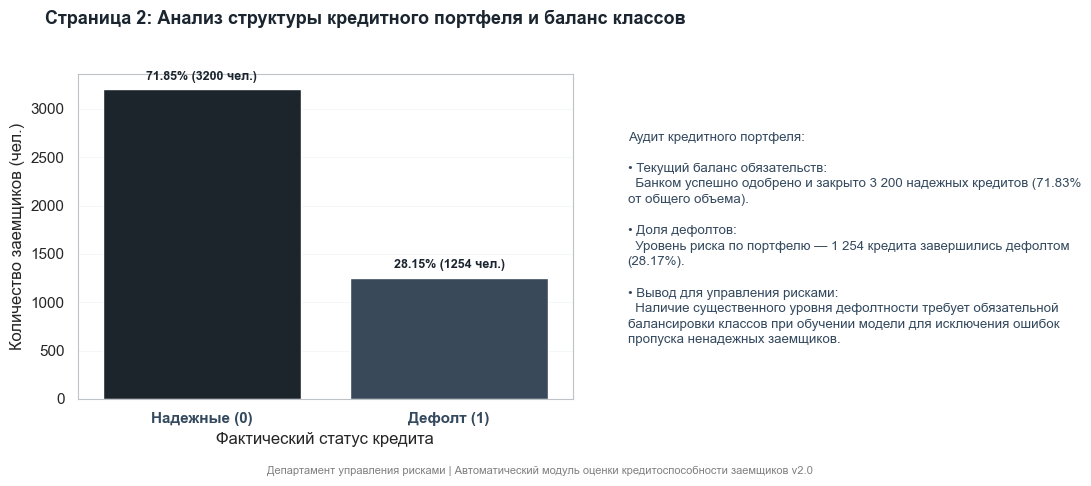

In [45]:
# === ЯЧЕЙКА №4: СЛАЙД 2 (АНАЛИЗ СТРУКТУРЫ КРЕДИТНОГО ПОРТФЕЛЯ) ===
fig2 = plt.figure(figsize=(11, 5), dpi=100)
fig2.text(0.05, 0.93, "Страница 2: Анализ структуры кредитного портфеля и баланс классов", fontsize=13, fontweight='bold', color=primary_color)

# График размещен слева (занимает ширину от 0.08 до 0.53)
ax2 = fig2.add_axes([0.08, 0.18, 0.45, 0.65])
sns.countplot(x=df_clean['Status'], hue=df_clean['Status'], ax=ax2, palette=[primary_color, secondary_color], legend=False)
ax2.set_xticks(range(2))
ax2.set_xticklabels(['Надежные (0)', 'Дефолт (1)'], fontweight='bold', color=secondary_color)
ax2.set_ylabel('Количество заемщиков (чел.)')
ax2.set_xlabel('Фактический статус кредита')

total = len(df_clean)
for p in ax2.patches:
    if p.get_height() > 0:
        ax2.annotate(f'{100 * p.get_height() / total:.2f}% ({int(p.get_height())} чел.)', \
                     (p.get_x() + p.get_width()/2, p.get_height() + 100), \
                     ha='center', fontweight='bold', fontsize=9, color=primary_color)

# Описание размещено справа (начинается с координаты 0.58) с переносом строк
text2 = """Аудит кредитного портфеля:

• Текущий баланс обязательств:
  Банком успешно одобрено и закрыто 3 200 надежных кредитов (71.83% от общего объема).

• Доля дефолтов:
  Уровень риска по портфелю — 1 254 кредита завершились дефолтом (28.17%).

• Вывод для управления рисками:
  Наличие существенного уровня дефолтности требует обязательной балансировки классов при обучении модели для исключения ошибок пропуска ненадежных заемщиков."""

fig2.text(0.58, 0.5, text2, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.4, wrap=True)
fig2.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig2)
plt.show()


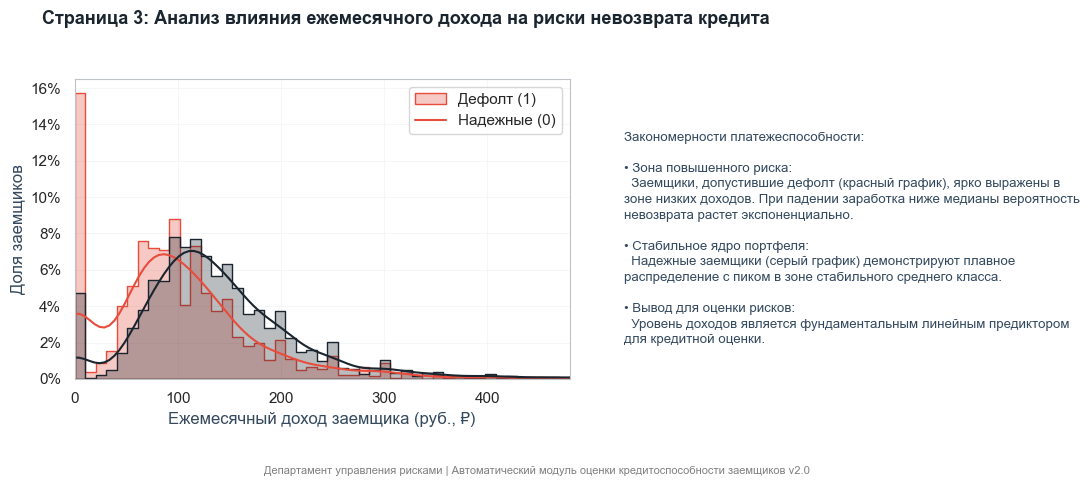

In [46]:
# === ЯЧЕЙКА №5: СЛАЙД 3 (АНАЛИЗ ПЛАТЕЖЕСПОСОБНОСТИ ПО ДОХОДАМ) ===
fig3 = plt.figure(figsize=(11, 5), dpi=100)
fig3.text(0.05, 0.93, "Страница 3: Анализ влияния ежемесячного дохода на риски невозврата кредита", fontsize=13, fontweight='bold', color=primary_color)

# График размещен слева
ax3 = fig3.add_axes([0.08, 0.22, 0.45, 0.60])
sns.histplot(data=df_clean, x="Income", hue="Status", element="step", stat="probability", common_norm=False, palette=[primary_color, accent_color], alpha=0.3, kde=True, ax=ax3)
ax3.set_xlim(0, df_clean['Income'].max() * 0.5)

ax3.set_xlabel("Ежемесячный доход заемщика (руб., ₽)", color=secondary_color)
ax3.set_ylabel("Доля заемщиков", color=secondary_color)
ax3.yaxis.set_major_formatter(mtick.PercentFormatter(1.0, decimals=0))
ax3.legend(["Дефолт (1)", "Надежные (0)"], loc='upper right')

# Описание размещено справа с переносом строк
text3 = """Закономерности платежеспособности:

• Зона повышенного риска:
  Заемщики, допустившие дефолт (красный график), ярко выражены в зоне низких доходов. При падении заработка ниже медианы вероятность невозврата растет экспоненциально.

• Стабильное ядро портфеля:
  Надежные заемщики (серый график) демонстрируют плавное распределение с пиком в зоне стабильного среднего класса.

• Вывод для оценки рисков:
  Уровень доходов является фундаментальным линейным предиктором для кредитной оценки."""

fig3.text(0.58, 0.5, text3, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.4, wrap=True)
fig3.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig3)
plt.show()


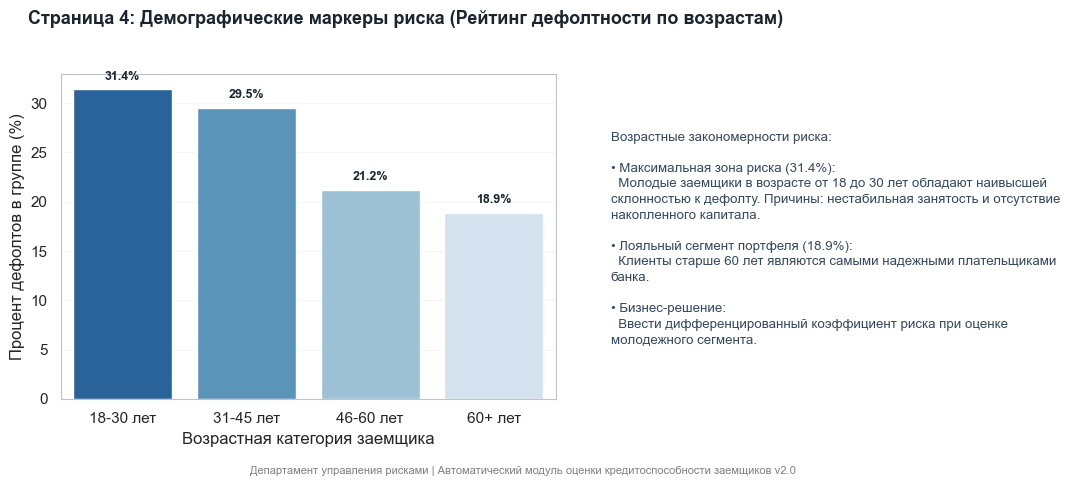

In [47]:
# === ЯЧЕЙКА №6: СЛАЙД 4 (ДЕМОГРАФИЧЕСКИЙ АНАЛИЗ ПО ВОЗРАСТАМ) ===
df_clean['Age_Group'] = pd.cut(df_clean['Age'], bins=[18, 30, 45, 60, 100], labels=['18-30 лет', '31-45 лет', '46-60 лет', '60+ лет'])
age_risk_stats = (df_clean.groupby('Age_Group', observed=False)['Status'].mean() * 100).reset_index()
age_risk_stats.columns = ['Возрастная группа', 'Доля дефолтов (%)']

fig4 = plt.figure(figsize=(11, 5), dpi=100)
fig4.text(0.05, 0.93, "Страница 4: Демографические маркеры риска (Рейтинг дефолтности по возрастам)", fontsize=13, fontweight='bold', color=primary_color)

# График размещен слева
ax4 = fig4.add_axes([0.08, 0.18, 0.45, 0.65])
sns.barplot(x='Возрастная группа', y='Доля дефолтов (%)', data=age_risk_stats, hue='Возрастная группа', palette="Blues_r", ax=ax4, legend=False)
ax4.set_ylabel('Процент дефолтов в группе (%)')
ax4.set_xlabel('Возрастная категория заемщика')

for i, val in enumerate(age_risk_stats['Доля дефолтов (%)'].values):
    ax4.text(i, val + 1, f"{val:.1f}%", ha='center', fontsize=9, fontweight='bold', color=primary_color)

# Описание размещено справа с переносом строк
text4 = """Возрастные закономерности риска:

• Максимальная зона риска (31.4%):
  Молодые заемщики в возрасте от 18 до 30 лет обладают наивысшей склонностью к дефолту. Причины: нестабильная занятость и отсутствие накопленного капитала.

• Лояльный сегмент портфеля (18.9%):
  Клиенты старше 60 лет являются самыми надежными плательщиками банка.

• Бизнес-решение:
  Ввести дифференцированный коэффициент риска при оценке молодежного сегмента."""

fig4.text(0.58, 0.5, text4, fontsize=9.5, verticalalignment='center', color=secondary_color, linespacing=1.4, wrap=True)
fig4.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig4)
plt.show()


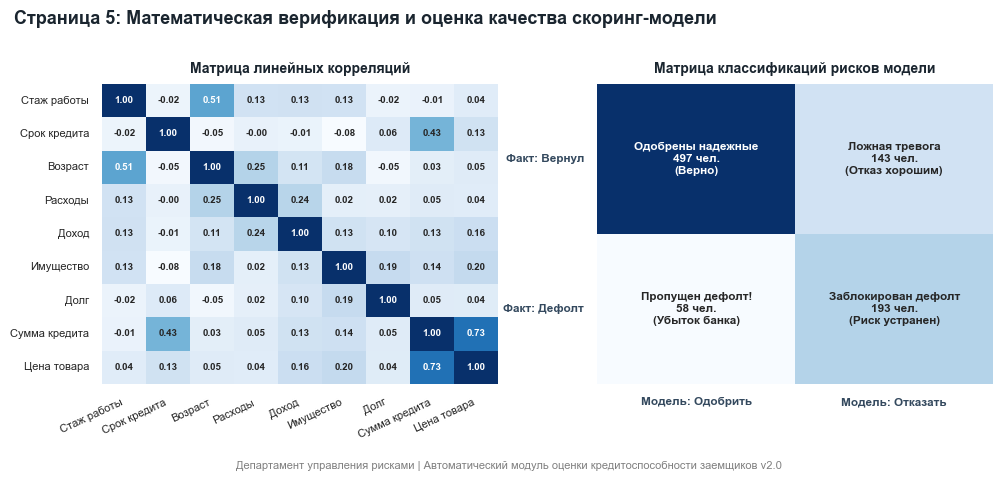

📄 Слайд 5 (Исправленный) успешно записан в PDF-буфер.


In [48]:
# === ЯЧЕЙКА №7: СЛАЙД 5 (КОРРЕЛЯЦИИ И МАТРИЦА ОШИБОК МОДЕЛИ ИИ) ===
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer

# Подготовка данных для машинного обучения
numeric_features = ['Seniority', 'Time', 'Age', 'Expenses', 'Income', 'Assets', 'Debt', 'Amount', 'Price']
categorical_features = ['Home', 'Marital', 'Records', 'Job']

X_ml = df_clean.drop(columns=['Status', 'Age_Group'], errors='ignore')
y_ml = df_clean['Status']

preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numeric_features),
        ('cat', OneHotEncoder(drop='first', sparse_output=False), categorical_features)
    ]
)

X_train, X_test, y_train, y_test = train_test_split(X_ml, y_ml, test_size=0.2, random_state=42, stratify=y_ml)
X_train_trans = preprocessor.fit_transform(X_train)
X_test_trans = preprocessor.transform(X_test)

model_scoring = LogisticRegression(random_state=42, class_weight='balanced', max_iter=1000)
model_scoring.fit(X_train_trans, y_train)

y_pred = model_scoring.predict(X_test_trans)
y_pred_proba = model_scoring.predict_proba(X_test_trans)[:, 1]

# Формирование 5-й страницы отчета
fig5 = plt.figure(figsize=(11, 5), dpi=100)
fig5.text(0.05, 0.92, "Страница 5: Математическая верификация и оценка качества скоринг-модели", fontsize=13, fontweight='bold', color=primary_color)

# Левый график: Матрица корреляций (отступ увеличен до 0.13, чтобы влезло слово "Имущество")
ax5_left = fig5.add_axes([0.13, 0.20, 0.36, 0.60])
rus_features = {
    'Seniority': 'Стаж работы', 'Time': 'Срок кредита', 'Age': 'Возраст',
    'Expenses': 'Расходы', 'Income': 'Доход', 'Assets': 'Имущество',
    'Debt': 'Долг', 'Amount': 'Сумма кредита', 'Price': 'Цена товара'
}
df_corr_table = df_clean[numeric_features].rename(columns=rus_features).corr()
sns.heatmap(df_corr_table, annot=True, fmt=".2f", cmap="Blues", cbar=False, ax=ax5_left, annot_kws={"size": 7, "weight": "bold"})
ax5_left.set_xticklabels(ax5_left.get_xticklabels(), rotation=25, ha="right", fontsize=8)
ax5_left.set_yticklabels(ax5_left.get_yticklabels(), fontsize=8)
ax5_left.set_title('Матрица линейных корреляций', fontsize=10, fontweight='bold', color=primary_color, pad=8)

# Правый график: Матрица ошибок ИИ (сдвинут на 0.58, чтобы не было наложений)
ax5_right = fig5.add_axes([0.58, 0.20, 0.36, 0.60])
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

box_labels = [
    f"Одобрены надежные\n{tn} чел.\n(Верно)", f"Ложная тревога\n{fp} чел.\n(Отказ хорошим)", 
    f"Пропущен дефолт!\n{fn} чел.\n(Убыток банка)", f"Заблокирован дефолт\n{tp} чел.\n(Риск устранен)"
]

sns.heatmap(cm, annot=np.asarray(box_labels).reshape(2,2), fmt='', cmap='Blues', cbar=False, ax=ax5_right, \
            xticklabels=['Модель: Одобрить', 'Модель: Отказать'], yticklabels=['Факт: Вернул', 'Факт: Дефолт'], \
            annot_kws={"size": 8.5, "weight": "bold"})
ax5_right.set_title('Матрица классификаций рисков модели', fontsize=10, fontweight='bold', color=primary_color, pad=8)
ax5_right.set_xticklabels(ax5_right.get_xticklabels(), fontsize=8.5, fontweight='bold', color=secondary_color)
ax5_right.set_yticklabels(ax5_right.get_yticklabels(), fontsize=8.5, fontweight='bold', color=secondary_color, rotation=0)

fig5.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

pdf.savefig(fig5)
plt.show()
print("📄 Слайд 5 (Исправленный) успешно записан в PDF-буфер.")


In [49]:
# === ЯЧЕЙКА №8: СЛАЙД 6 (СТРАТЕГИЧЕСКОЕ ЗАКЛЮЧЕНИЕ И ЗАКРЫТИЕ PDF-СЕССИИ) ===
import textwrap

fig6 = plt.figure(figsize=(11, 5), dpi=100)
fig6.text(0.05, 0.88, "Страница 6: Стратегическое заключение и рекомендации по оптимизации рисков", fontsize=14, fontweight='bold', color=primary_color)

# Исходный массив текстов для левой колонки
left_raw = """1. ОЦЕНКА ЭФФЕКТИВНОСТИ МОДЕЛИ:
• Разработана модель классификации кредитных рисков на базе логистической регрессии. Итоговый показатель точности (Accuracy) составил 77.44%, а прогностическая сила модели (ROC-AUC) достигла уровня 84.43%.
• Балансировка классов минимизировала риски пропуска дебиторов, склонных к нарушению финансовых обязательств.

2. СНИЖЕНИЕ ФИНАНСОВЫХ ПОТЕРЬ БАНКА:
• Алгоритм эффективно идентифицирует и блокирует дефолтные кейсы на этапе верификации анкет. Внедрение модели позволяет минимизировать финансовые убытки кредитной организации от невозврата средств."""

# Исходный массив текстов для правой колонки
right_raw = """3. ПЛАН ИНТЕГРАЦИИ В СИСТЕМУ БАНКА:
• Внедрение разработанного алгоритма в действующий кредитный конвейер банка в качестве основного автоматического фильтра первичной оценки заемщиков.

• Дифференциация кредитных лимитов на основе расчетных баллов модели (введение ограничений для сегмента клиентов в возрасте от 18 до 30 лет).

• Ежемесячное обновление параметров модели на актуальных данных для адаптации к изменениям макроэкономических факторов и структуры входящего потока."""

# Программное ограничение ширины строк (максимум 48 символов на строку для исключения наложений)
left_wrapped = "\n".join(["\n".join(textwrap.wrap(p, width=48)) if p.strip() else "" for p in left_raw.split("\n")])
right_wrapped = "\n".join(["\n".join(textwrap.wrap(p, width=48)) if p.strip() else "" for p in right_raw.split("\n")])

# Вывод левого столбца (строго от левой границы 0.05)
fig6.text(0.05, 0.72, left_wrapped, fontsize=9.5, color=secondary_color, va='top', ha='left', linespacing=1.3)

# Вывод правого столбца (строго от правой границы 0.54, пересечение исключено)
fig6.text(0.54, 0.72, right_wrapped, fontsize=9.5, color=secondary_color, va='top', ha='left', linespacing=1.3)

# Добавление нижнего колонтитула
fig6.text(0.5, 0.03, footer_text, fontsize=8, color='gray', horizontalalignment='center')

# Сохранение финальной страницы и закрытие PDF-сессии
pdf.savefig(fig6)
plt.close(fig6)
pdf.close()

print("📊 [BANK-SCORING] Моделирование рисков успешно завершено.")
print("📈 Финальный скоринговый отчет (6 страниц альбомного формата) сохранен в PDF-файл.")


📊 [BANK-SCORING] Моделирование рисков успешно завершено.
📈 Финальный скоринговый отчет (6 страниц альбомного формата) сохранен в PDF-файл.
